<h3 style="font-size:17px; font-weight:bold;">Naive Bayes Classification</h3>

<h5 style="font-size:14px;">

**Definiție:** Naive Bayes este un algoritm de clasificare bazat pe Teorema lui Bayes. Este un model probabilistic care calculează probabilitatea ca o observație să aparțină unei clase, presupunând că variabilele independente sunt condițional independente între ele. Este utilizat frecvent pentru clasificare binară și multiclasă.

**Tipuri:**<br>
- **Gaussian Naive Bayes:** utilizat pentru date continue, presupune distribuție normală.<br>
- **Multinomial Naive Bayes:** utilizat frecvent în clasificarea textului (ex: număr de apariții ale cuvintelor).<br>
- **Bernoulli Naive Bayes:** utilizat pentru date binare (0/1).<br>

**Elemente teoretice:**<br>
- **Teorema lui Bayes:** P(C|X) = (P(X|C) · P(C)) / P(X)<br>
- **P(C|X):** probabilitatea posterioară a clasei C dat fiind X.<br>
- **P(X|C):** verosimilitatea (likelihood) – probabilitatea datelor X pentru clasa C.<br>
- **P(C):** probabilitatea priori a clasei.<br>
- **P(X):** probabilitatea totală a datelor (constantă pentru toate clasele).<br>
- **Ipoteza de independență:** caracteristicile sunt independente condițional față de clasă.<br>

**Presupuneri ale Naive Bayes:**<br>
- Variabilele independente sunt condițional independente.<br>
- Distribuția datelor respectă tipul modelului ales (ex: normală pentru Gaussian).<br>
- Datele de antrenare sunt reprezentative pentru populație.<br><br>

</h5>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
patients = pd.read_csv("../data/breast_cancer.csv")

<h5 style="font-size:14px;">

**Descrierea setului de date:** Setul de date *Breast Cancer (Wisconsin)* conține informații despre tumori mamare, inclusiv caracteristici celulare măsurate numeric și diagnosticul asociat (benign/malign). Datele sunt folosite pentru analiza clasificării tumorilor și pentru construirea unui model **Naive Bayes**.

**Structura datelor:**<br>
- **id:** identificator unic al probei.<br>
- **diagnosis:** tipul tumorii (M = malign, B = benign).<br>
- **radius_mean:** media razei celulelor.<br>
- **texture_mean:** media texturii celulelor.<br>
- **perimeter_mean:** media perimetrului celulelor.<br>
- **area_mean:** media ariei celulelor.<br>
- **smoothness_mean:** media netezimii celulelor.<br>
- **compactness_mean:** media compactității celulelor.<br>
- **concavity_mean:** media concavității celulelor.<br>
- **concave points_mean:** media punctelor concave ale celulelor.<br>
- **symmetry_mean:** media simetriei celulelor.<br>
- **fractal_dimension_mean:** media dimensiunii fractale.<br>
- **radius_se:** eroarea standard a razei.<br>
- **texture_se:** eroarea standard a texturii.<br>
- **perimeter_se:** eroarea standard a perimetrului.<br>
- **area_se:** eroarea standard a ariei.<br>
- **smoothness_se:** eroarea standard a netezimii.<br>
- **compactness_se:** eroarea standard a compactității.<br>
- **concavity_se:** eroarea standard a concavității.<br>
- **concave points_se:** eroarea standard a punctelor concave.<br>
- **symmetry_se:** eroarea standard a simetriei.<br>
- **fractal_dimension_se:** eroarea standard a dimensiunii fractale.<br>
- **radius_worst:** cea mai mare valoare a razei.<br>
- **texture_worst:** cea mai mare valoare a texturii.<br>
- **perimeter_worst:** cea mai mare valoare a perimetrului.<br>
- **area_worst:** cea mai mare valoare a ariei.<br>
- **smoothness_worst:** cea mai mare valoare a netezimii.<br>
- **compactness_worst:** cea mai mare valoare a compactității.<br>
- **concavity_worst:** cea mai mare valoare a concavității.<br>
- **concave points_worst:** cea mai mare valoare a punctelor concave.<br>
- **symmetry_worst:** cea mai mare valoare a simetriei.<br>
- **fractal_dimension_worst:** cea mai mare valoare a dimensiunii fractale.<br>

**Variabile numerice utilizate în analiză:**<br>
- **radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, compactness_mean, concavity_mean, concave points_mean, symmetry_mean, fractal_dimension_mean**<br>
- **radius_se, texture_se, perimeter_se, area_se, smoothness_se, compactness_se, concavity_se, concave points_se, symmetry_se, fractal_dimension_se**<br>
- **radius_worst, texture_worst, perimeter_worst, area_worst, smoothness_worst, compactness_worst, concavity_worst, concave points_worst, symmetry_worst, fractal_dimension_worst**<br>

**Observație:** În cadrul analizelor statistice și modelării clasificării tumorilor (ex. **Naive Bayes**) vor fi utilizate variabilele numerice pentru a clasifica tumorile ca **maligne** sau **benigne**, pe baza probabilităților estimate din caracteristicile celulare.

</h5>

In [3]:
patients.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [4]:
patients.tail(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
559,925291,B,11.51,23.93,74.52,403.5,0.09261,0.10210,0.11120,0.04105,...,12.480,37.16,82.28,474.2,0.12980,0.25170,0.3630,0.09653,0.2112,0.08732
560,925292,B,14.05,27.15,91.38,600.4,0.09929,0.11260,0.04462,0.04304,...,15.300,33.17,100.20,706.7,0.12410,0.22640,0.1326,0.10480,0.2250,0.08321
561,925311,B,11.20,29.37,70.67,386.0,0.07449,0.03558,0.00000,0.00000,...,11.920,38.30,75.19,439.6,0.09267,0.05494,0.0000,0.00000,0.1566,0.05905
562,925622,M,15.22,30.62,103.40,716.9,0.10480,0.20870,0.25500,0.09429,...,17.520,42.79,128.70,915.0,0.14170,0.79170,1.1700,0.23560,0.4089,0.14090
563,926125,M,20.92,25.09,143.00,1347.0,0.10990,0.22360,0.31740,0.14740,...,24.290,29.41,179.10,1819.0,0.14070,0.41860,0.6599,0.25420,0.2929,0.09873
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.22160,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.16280,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.14180,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.26500,0.4087,0.12400
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.00000,0.2871,0.07039


In [5]:
patients.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [6]:
patients.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
patients.shape

(569, 32)

In [8]:
patients.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')

In [9]:
patients.dtypes

id                           int64
diagnosis                      str
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [10]:
patients.isnull().sum()

id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [11]:
patients.duplicated().sum()

np.int64(0)

In [12]:
patients.nunique()

id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: i

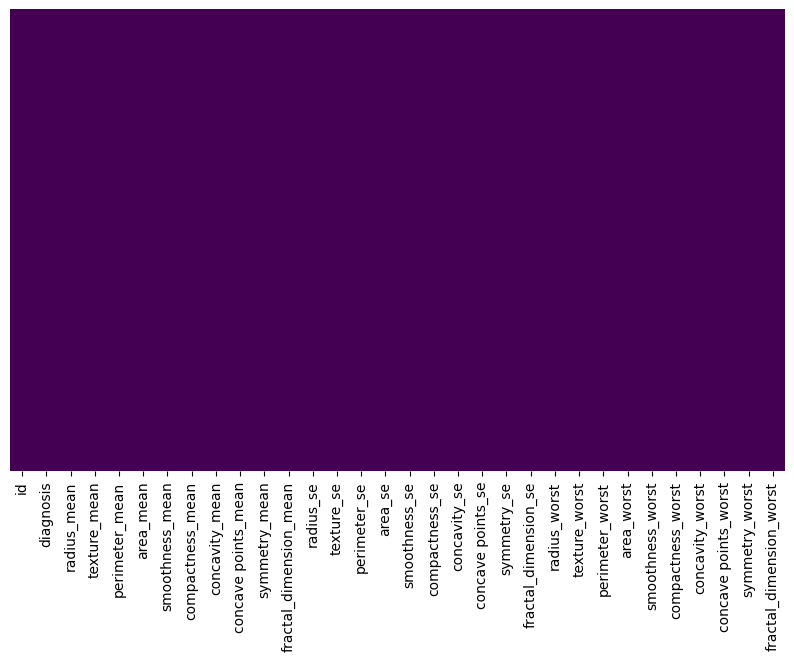

In [13]:
plt.figure(figsize=(10, 6))
sns.heatmap(patients.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.show()

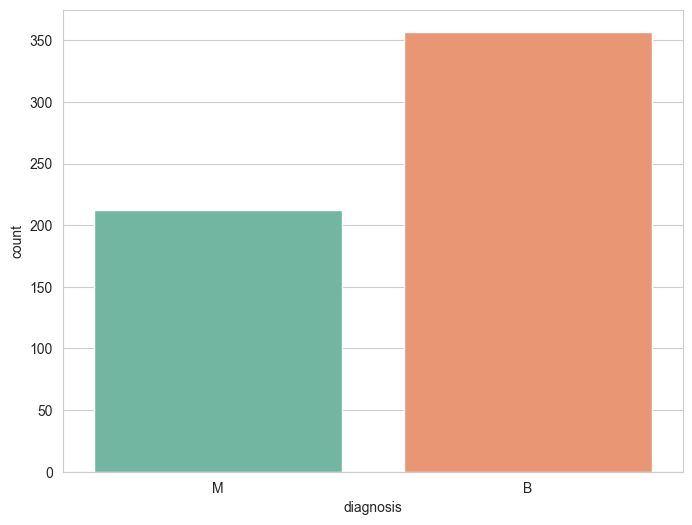

In [14]:
sns.set_style('whitegrid')
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.show()

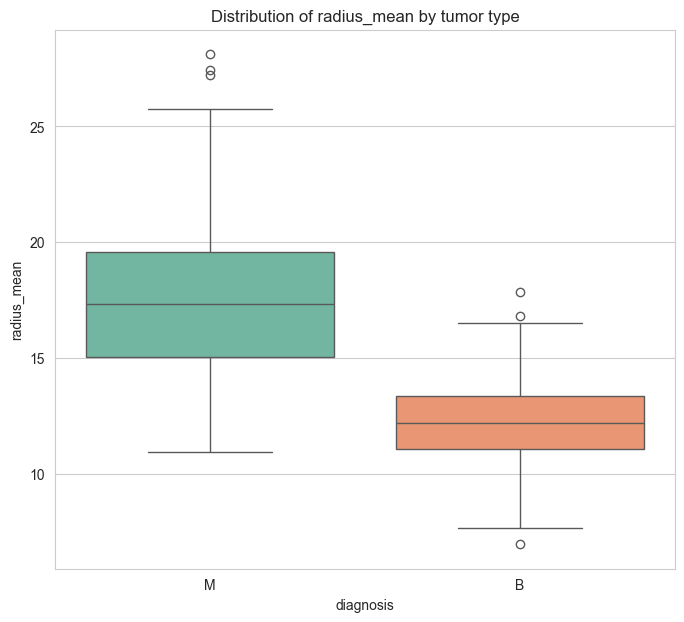

In [15]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='radius_mean', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of radius_mean by tumor type")
plt.show()

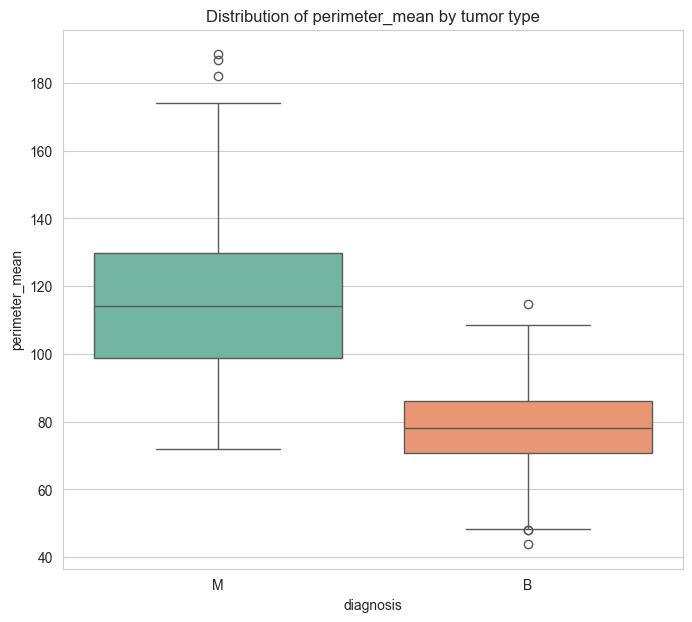

In [16]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='perimeter_mean', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of perimeter_mean by tumor type")
plt.show()

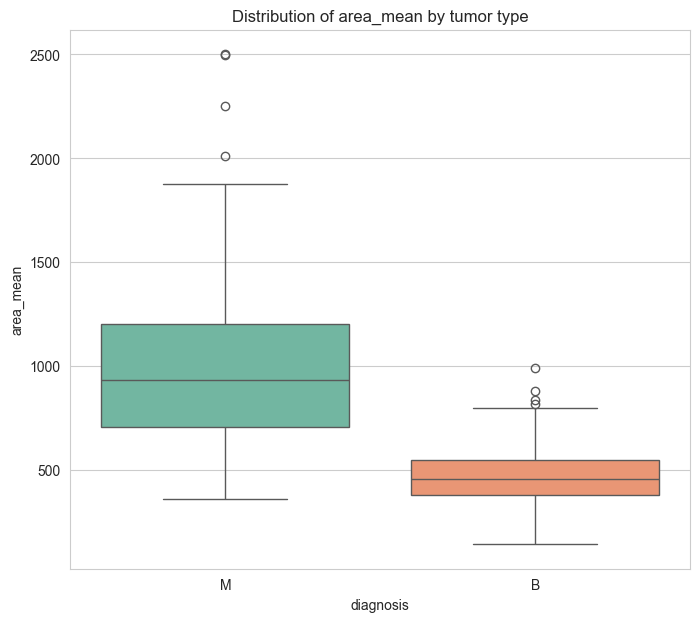

In [17]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='area_mean', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of area_mean by tumor type")
plt.show()

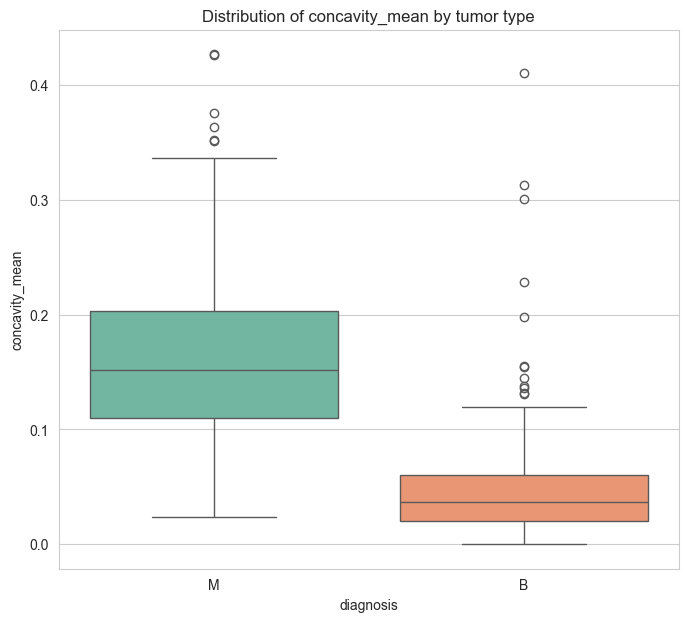

In [18]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='concavity_mean', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of concavity_mean by tumor type")
plt.show()

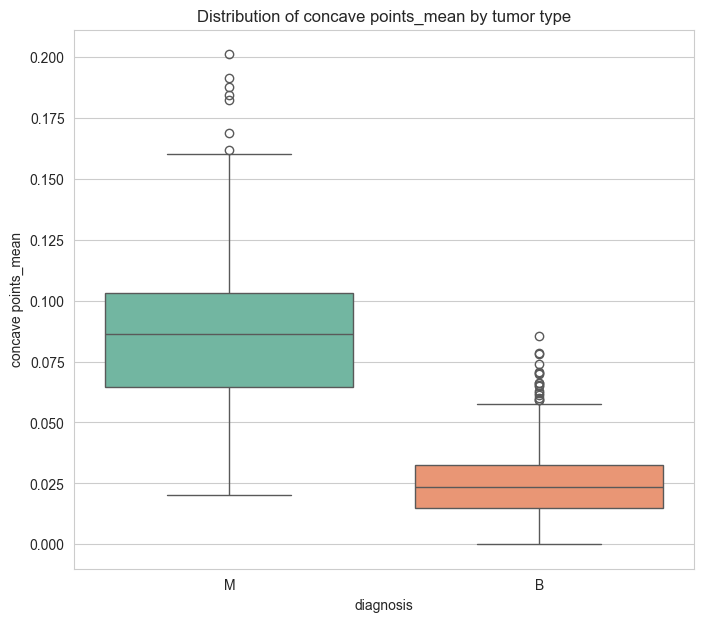

In [19]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='concave points_mean', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of concave points_mean by tumor type")
plt.show()

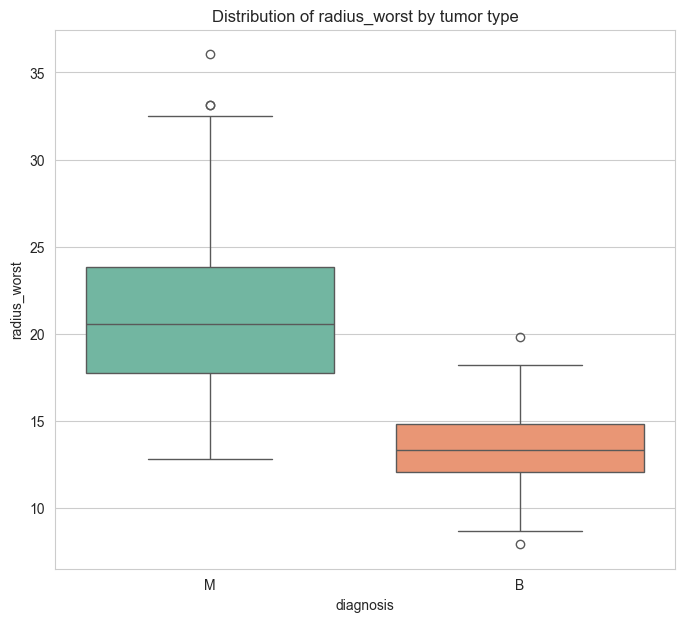

In [20]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='radius_worst', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of radius_worst by tumor type")
plt.show()

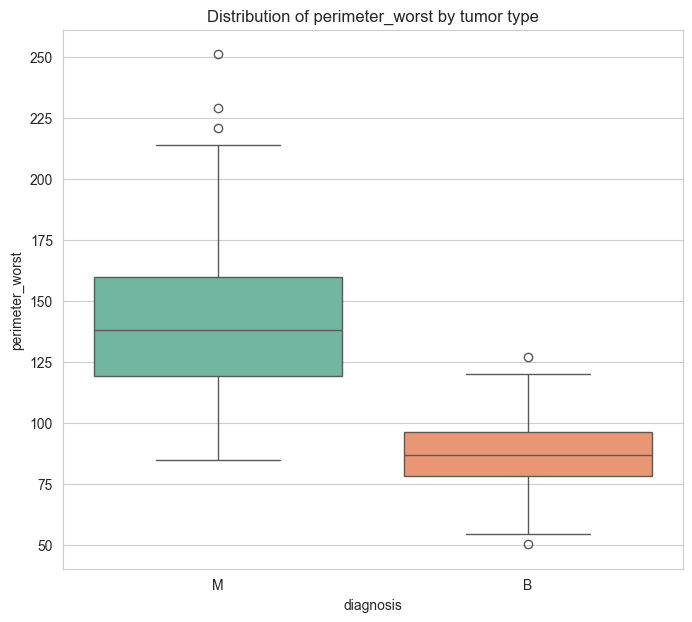

In [21]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='perimeter_worst', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of perimeter_worst by tumor type")
plt.show()

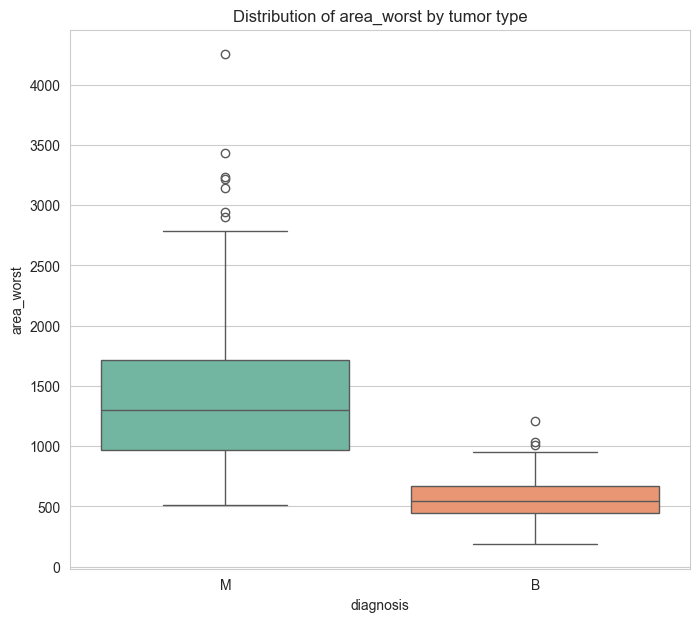

In [22]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='area_worst', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of area_worst by tumor type")
plt.show()

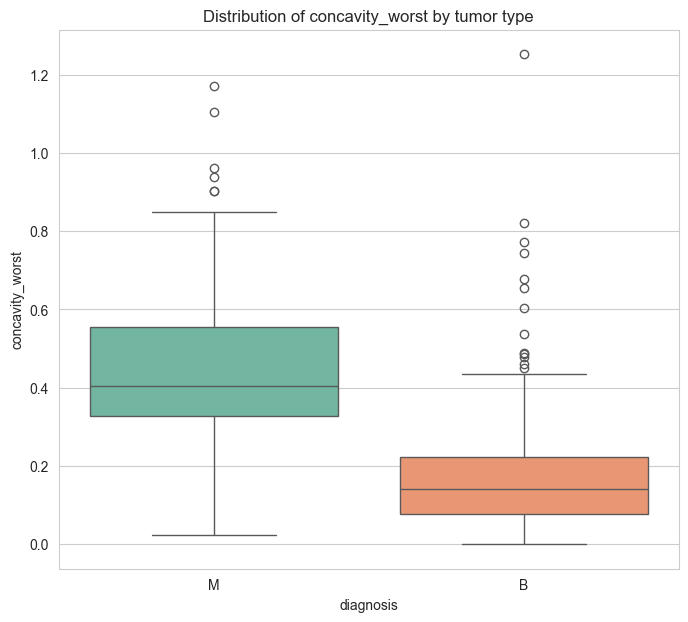

In [23]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='concavity_worst', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of concavity_worst by tumor type")
plt.show()

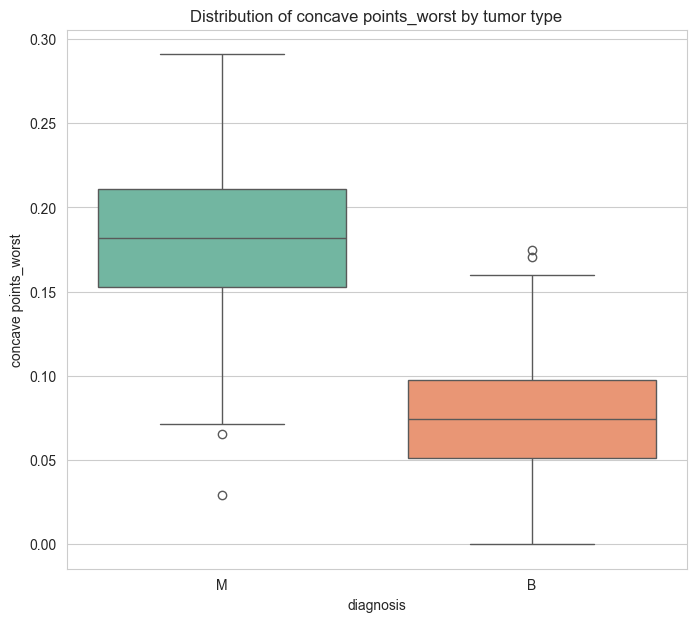

In [24]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='diagnosis', y='concave points_worst', hue='diagnosis', data=patients, palette='Set2', legend=False)
plt.title("Distribution of concave points_worst by tumor type")
plt.show()

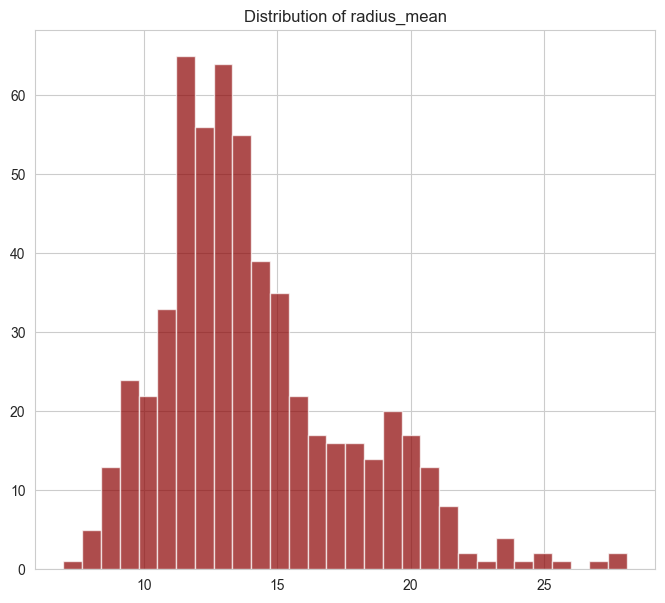

In [25]:
plt.figure(figsize=(8, 7))
patients['radius_mean'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of radius_mean")
plt.show()

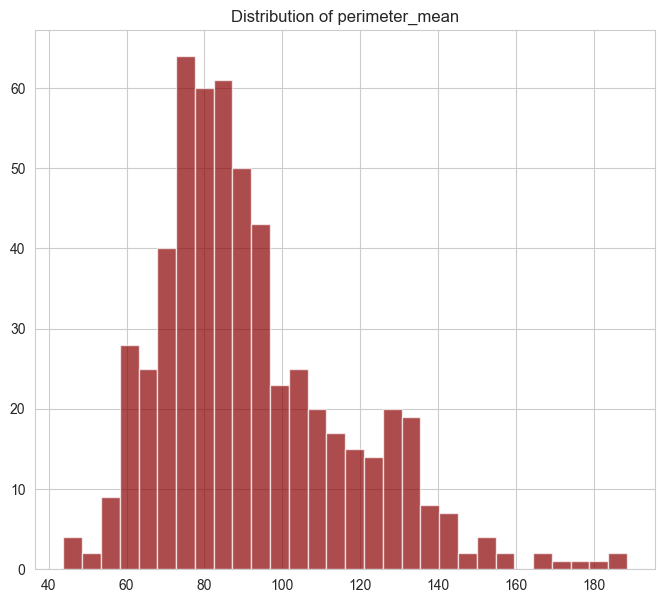

In [26]:
plt.figure(figsize=(8, 7))
patients['perimeter_mean'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of perimeter_mean")
plt.show()

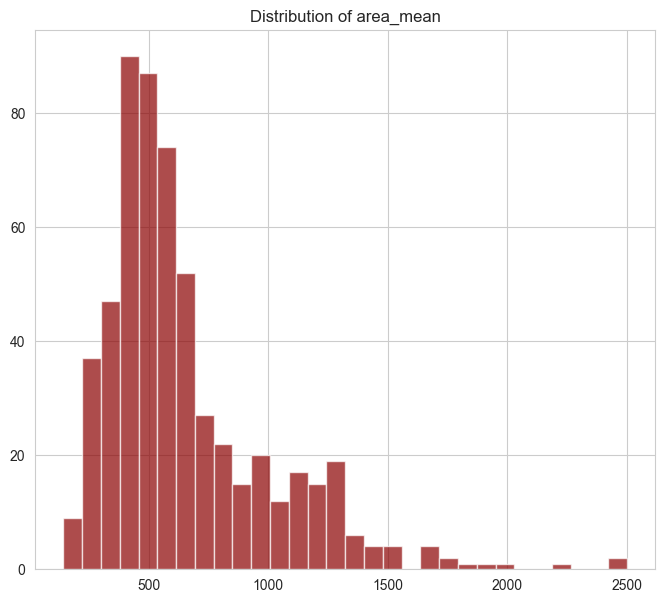

In [27]:
plt.figure(figsize=(8, 7))
patients['area_mean'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of area_mean")
plt.show()

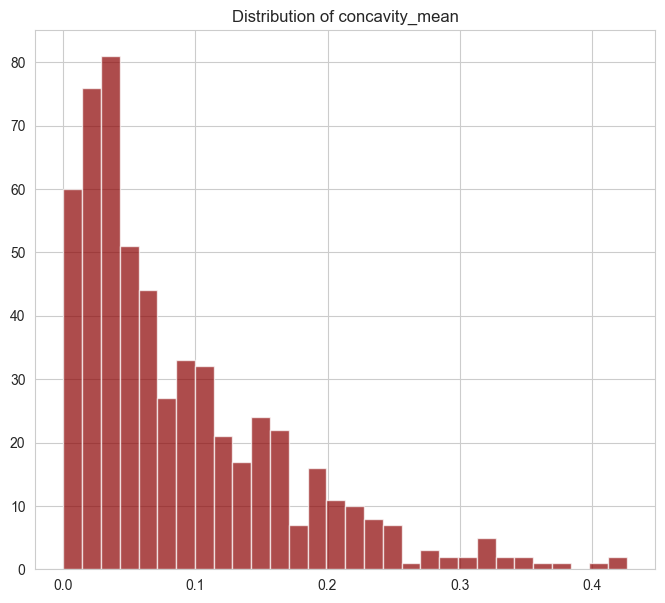

In [28]:
plt.figure(figsize=(8, 7))
patients['concavity_mean'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of concavity_mean")
plt.show()

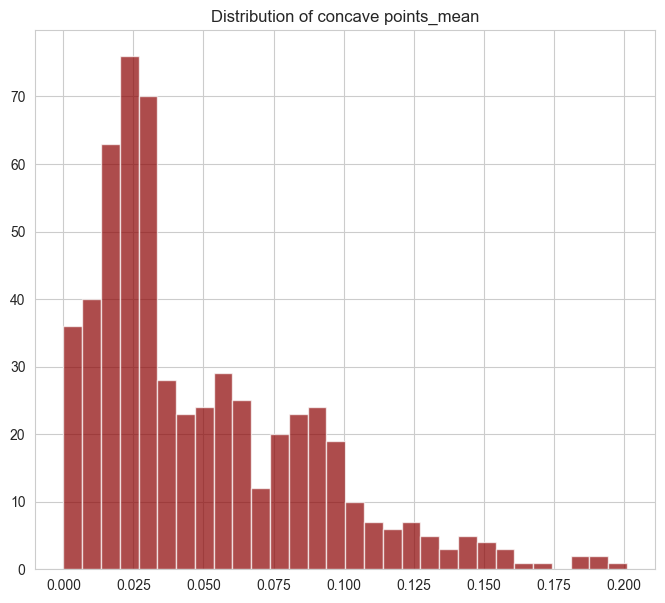

In [29]:
plt.figure(figsize=(8, 7))
patients['concave points_mean'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of concave points_mean")
plt.show()

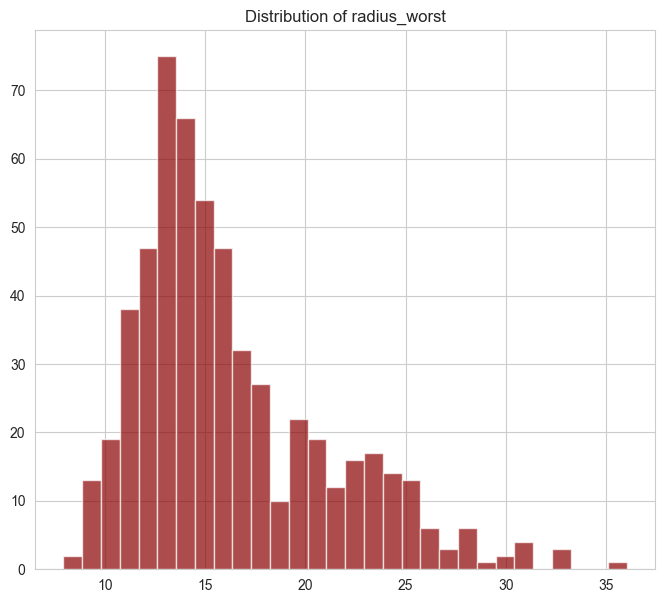

In [30]:
plt.figure(figsize=(8, 7))
patients['radius_worst'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of radius_worst")
plt.show()

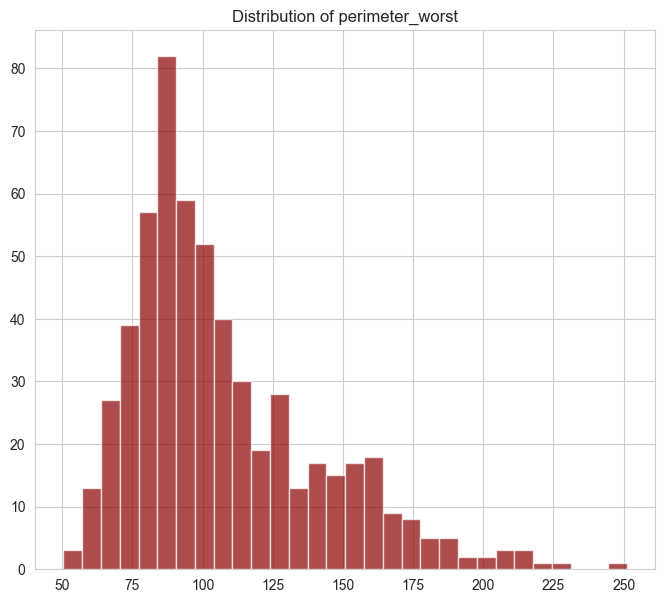

In [31]:
plt.figure(figsize=(8, 7))
patients['perimeter_worst'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of perimeter_worst")
plt.show()

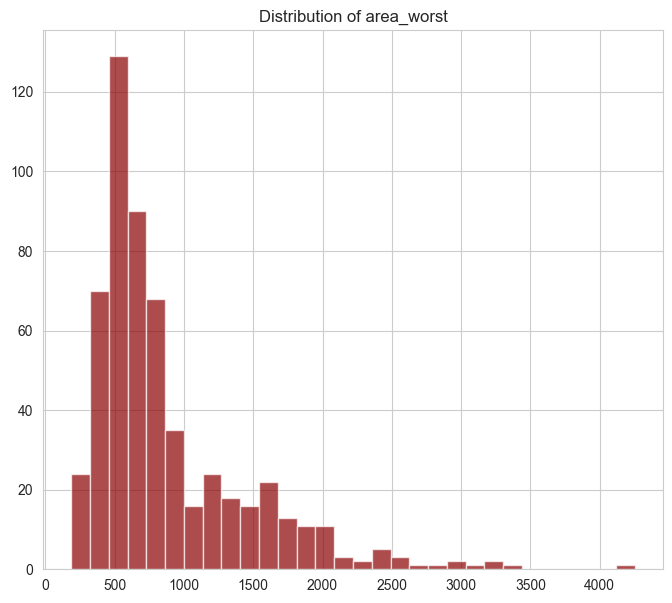

In [32]:
plt.figure(figsize=(8, 7))
patients['area_worst'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of area_worst")
plt.show()

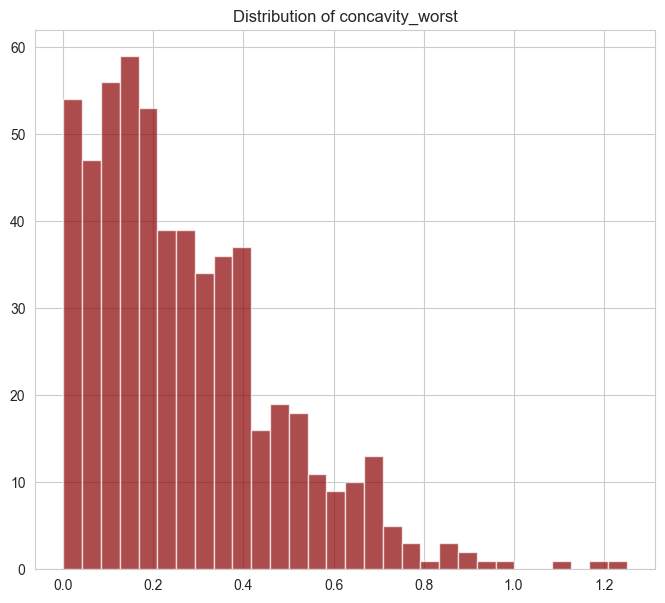

In [33]:
plt.figure(figsize=(8, 7))
patients['concavity_worst'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of concavity_worst")
plt.show()

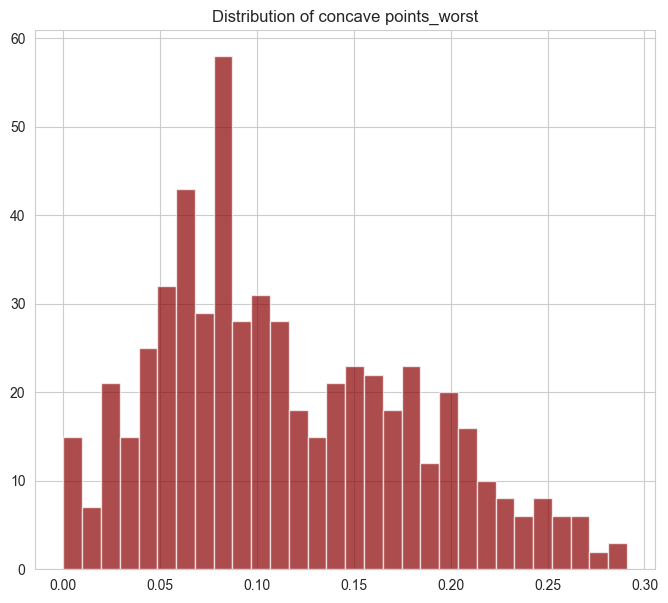

In [34]:
plt.figure(figsize=(8, 7))
patients['concave points_worst'].hist(bins=30, color='darkred', alpha=0.7)
plt.title("Distribution of concave points_worst")
plt.show()

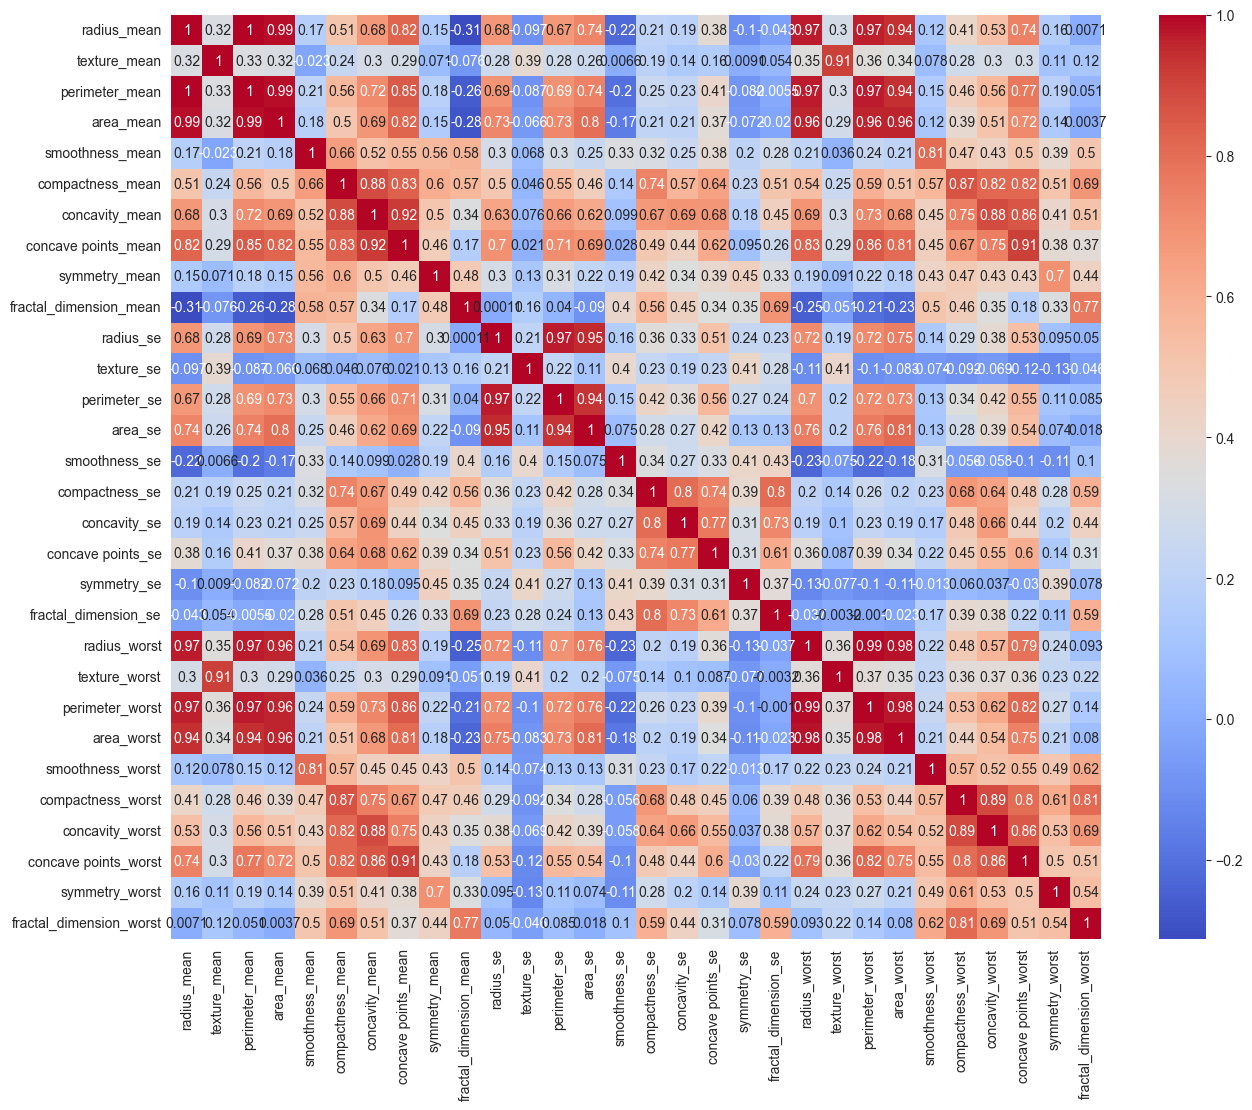

In [35]:
plt.figure(figsize=(15, 12))
sns.heatmap(patients.iloc[:, 2:].corr(), annot=True, cmap='coolwarm')
plt.show()

In [36]:
diagnosis_dummies = pd.get_dummies(patients['diagnosis'], drop_first=True).astype('uint8')

In [37]:
patients.drop('diagnosis', axis=1, inplace=True)
patients = pd.concat([patients, diagnosis_dummies], axis=1)

In [38]:
x = patients.drop(['id', 'M'], axis=1)
y = patients['M']

In [39]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)

In [40]:
print("Training set size:", x_train.shape)
print("Test set size:", x_test.shape)

Training set size: (455, 30)
Test set size: (114, 30)


In [41]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [42]:
logmodel = GaussianNB()
logmodel.fit(x_train_scaled, y_train)

GaussianNB()

In [43]:
predictions = logmodel.predict(x_test_scaled)

In [44]:
accuracy_score(y_test, predictions)

0.9649122807017544

In [45]:
confusion_matrix(y_test, predictions)

array([[70,  1],
       [ 3, 40]])

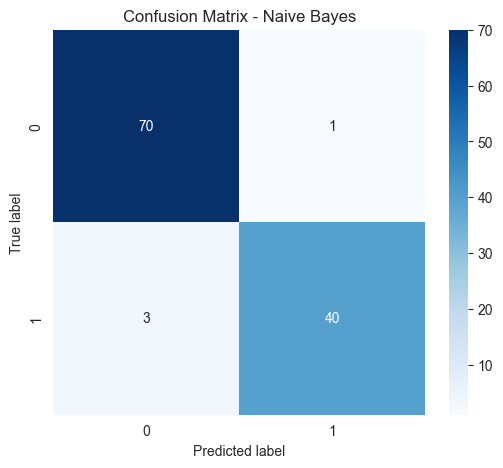

In [46]:
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [47]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [48]:
new_patient = [
    14.5,   # radius_mean
    20.2,   # texture_mean
    94.0,   # perimeter_mean
    650.0,  # area_mean
    0.10,   # smoothness_mean
    0.15,   # compactness_mean
    0.12,   # concavity_mean
    0.08,   # concave points_mean
    0.18,   # symmetry_mean
    0.06,   # fractal_dimension_mean
    0.40,   # radius_se
    1.20,   # texture_se
    2.80,   # perimeter_se
    40.0,   # area_se
    0.005,  # smoothness_se
    0.02,   # compactness_se
    0.03,   # concavity_se
    0.01,   # concave points_se
    0.02,   # symmetry_se
    0.003,  # fractal_dimension_se
    16.0,   # radius_worst
    25.0,   # texture_worst
    105.0,  # perimeter_worst
    800.0,  # area_worst
    0.14,   # smoothness_worst
    0.30,   # compactness_worst
    0.35,   # concavity_worst
    0.15,   # concave points_worst
    0.30,   # symmetry_worst
    0.08    # fractal_dimension_worst
]

In [49]:
new_patient = pd.DataFrame([new_patient], columns=x.columns)

new_patient = scaler.transform(new_patient)

prediction = logmodel.predict(new_patient)
probability = logmodel.predict_proba(new_patient)

if prediction[0] == 1:
    print("\nResult: MALIGNANT tumor")
else:
    print("\nResult: BENIGN tumor")

print("Probabilities:", probability)


Result: MALIGNANT tumor
Probabilities: [[0.01762384 0.98237616]]


<h5 style="font-size:14px;">

**Interpretarea coeficienților:** Coeficienții obținuți din Naive Bayes arată cât de mult influențează fiecare caracteristică șansa ca o tumoră să fie malignă. De exemplu, variabile precum **radius_mean**, **perimeter_mean**, **area_mean**, **concavity_mean** și **concave points_mean** au un impact mai mare, ceea ce indică faptul că valori crescute în aceste caracteristici cresc probabilitatea ca tumora să fie malignă. Alte variabile precum **smoothness_mean**, **symmetry_mean** sau **fractal_dimension_mean** au un impact mai redus asupra predicției.<br><br>

**Interpretarea matricei de confuzie și a metricilor:** Modelul Naive Bayes prezice corect majoritatea cazurilor. Din matricea de confuzie [[70, 1], [3, 40]] rezultă:  
- 70 tumori Benign clasificate corect, 1 false positive  
- 40 tumori Malign clasificate corect, 3 false negative  
- Metricile de evaluare (precision, recall, f1-score) arată o **acuratețe globală de 0.96**, cu performanță foarte bună pe ambele clase: Benign (recall 0.99) și Malign (recall 0.93).<br><br>

**Recomandare:** Cele mai importante variabile pentru predicții precise sunt cele legate de dimensiunea și concavitatea tumorii. Alte caracteristici pot fi incluse, dar influența lor este mai redusă. Modelul Naive Bayes scalat arată performanțe excelente, însă se pot testa și modele mai complexe pentru a reduce și mai mult erorile, în special false negative-urile.

</h5>